In [1]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc 
import time
import copy
import math
from torchvision.transforms import RandAugment
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchinfo
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision import transforms
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, precision_score, recall_score
from PIL import Image


import hashlib
import shutil
import ssl
import tempfile
import warnings
from pathlib import Path
from urllib.error import URLError
from urllib.parse import urlparse
from urllib.request import HTTPSHandler, Request, build_opener

import torch
import torch.nn as nn
from torch.hub import get_dir as get_torch_hub_dir
from torchvision import models
from torchvision.models import VGG16_Weights, vgg16

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:

base_path = 'LungHist700_combined/data/'
csv_path = base_path + 'data.csv'
images_base = base_path + 'images/' 

batch_size = 32
num_epochs = 100
learning_rate = 3e-4
random_seed = 42

def seed_everything(seed):
    random.seed(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)


def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % 2**32

    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(random_seed)

g = torch.Generator()
g.manual_seed(random_seed)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo em uso: {device}\n")

full_df = pd.read_csv(csv_path)
superclass_map = {'aca': 0, 'ssc': 1, 'scc': 1, 'nor': 2}
full_df['label'] = full_df['superclass'].map(superclass_map)

print("Dados carregados e mapeados com sucesso!")
print("Total de linhas:", len(full_df))
print("Colunas:", full_df.columns.tolist())
print("Exemplo das 5 primeiras linhas:\n", full_df.head())
print("Distribuição de resolução:\n", full_df['resolution'].value_counts())


def get_dataframe_no_loss(df_input):
    return df_input.sample(frac=1, random_state=random_seed).reset_index(drop=True)

print("Função de processamento de dados atualizada!")

Dispositivo em uso: cpu

Dados carregados e mapeados com sucesso!
Total de linhas: 691
Colunas: ['superclass', 'subclass', 'resolution', 'image_id', 'patient_id', 'label']
Exemplo das 5 primeiras linhas:
   superclass subclass resolution  image_id  patient_id  label
0        aca       bd        40x       901           1      0
1        aca       bd        40x       902           1      0
2        aca       bd        40x       903           1      0
3        aca       bd        40x       904           1      0
4        aca       bd        40x       905           1      0
Distribuição de resolução:
 resolution
20x    359
40x    332
Name: count, dtype: int64
Função de processamento de dados atualizada!


In [3]:
class LungHistDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):

        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        superclass = row['superclass']
        image_id = row['image_id']
        resolution = row['resolution']

        subclass = (
            row['subclass']
            if not pd.isna(row['subclass'])
            else ""
        )

        file_prefix = superclass

        if superclass == 'scc':

            folder_name = 'ssc'
            file_prefix = 'ssc'

        else:

            folder_name = superclass

        class_dir = os.path.join(
            self.root_dir,
            folder_name
        )

        potential_filenames = [

            f"{image_id}.jpg",

            f"{file_prefix}_{subclass}_{resolution}_{image_id}.jpg",

            f"{file_prefix}_{resolution}_{image_id}.jpg",

            f"{image_id}.png",

            f"{file_prefix}_{subclass}_{resolution}_{image_id}.png",

            f"{file_prefix}_{resolution}_{image_id}.png"
        ]

        img_path = None

        for fname in potential_filenames:

            full_path = os.path.join(
                class_dir,
                fname
            )

            if os.path.exists(full_path):

                img_path = full_path
                break

        if img_path is None and os.path.exists(class_dir):

            import glob

            search_pattern = os.path.join(
                class_dir,
                f"*{image_id}.*"
            )

            found_files = glob.glob(search_pattern)

            if found_files:

                img_path = found_files[0]

        try:

            if img_path is None:

                raise FileNotFoundError(
                    "Imagem não encontrada"
                )

            image = Image.open(img_path).convert("RGB")

        except Exception as e:

            print("\n" + "=" * 60)
            print("ERRO AO CARREGAR IMAGEM")
            print("=" * 60)

            print(f"ID: {image_id}")
            print(f"Classe: {superclass}")
            print(f"Resolution: {resolution}")
            print(f"Pasta: {class_dir}")
            print(f"Path encontrado: {img_path}")
            print(f"Erro: {e}")

            image = Image.new('RGB', (224, 224))

        label = row['label']

        if self.transform:

            image = self.transform(image)

        return image, label


print("✓ Classe Dataset definida com sucesso!")

✓ Classe Dataset definida com sucesso!


In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandAugment(num_ops=2, magnitude=5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),

   
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("RandAugment configurado com sucesso.")

RandAugment configurado com sucesso.


In [5]:
def print_stats_table(df_name, train_df, val_df, test_df):
    c_train = train_df['label'].value_counts().to_dict()
    c_val   = val_df['label'].value_counts().to_dict()
    c_test  = test_df['label'].value_counts().to_dict()
    idx_to_class = {0: 'ACA', 1: 'SCC', 2: 'NOR'}
    
    print(f"\nCONJUNTO DE DADOS: {df_name}")
    print("-" * 42)
    print(f"{'CLASSE':<8} | {'TREINO':<8} | {'VALIDAÇÃO':<8} | {'TESTE':<8}")
    print("-" * 42)
    for idx in range(3): 
        name = idx_to_class[idx]
        print(f"{name:<8} | {c_train.get(idx, 0):<8} | {c_val.get(idx, 0):<8} | {c_test.get(idx, 0):<8}")
    print("-" * 42 + "\n")

print("Função print_stats_table definida com sucesso!")

Função print_stats_table definida com sucesso!


In [6]:
def make_weighted_sampler(df_train, label_col='label', seed=42):

    class_counts = df_train[label_col].value_counts().sort_index().values

    # pesos inversos
    class_weights = 1.0 / class_counts

    sample_weights = [
        class_weights[label]
        for label in df_train[label_col]
    ]

    # generator fixo
    g = torch.Generator()
    g.manual_seed(seed)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=g
    )

    return sampler

print("Função make_weighted_sampler definida com sucesso!")

Função make_weighted_sampler definida com sucesso!


In [7]:

def get_reproducible_ids(df, resolution):

    if resolution == '20x':
        train_ids = [2,3,4,5,7,8,12,14,15,16,17,18,20,21,23,24,25,26,28,29,30,33,36,37,38,39,41,42,45]
        val_ids   = [1,6,27,32,44]
        test_ids  = [9,13,31,40]

    elif resolution == '40x':
        train_ids = [2,6,8,9,10,12,13,14,16,18,19,21,22,24,28,29,31,33,34,35,36,38,40,44]
        val_ids   = [1,4,17,26,30,37,45]
        test_ids  = [11,15,20,25,32,43]

    else:
        raise ValueError("Resolution deve ser '20x' ou '40x'")

    train_df = df[df['patient_id'].isin(train_ids)]
    val_df   = df[df['patient_id'].isin(val_ids)]
    test_df  = df[df['patient_id'].isin(test_ids)]

    return train_df, val_df, test_df



def process_resolution(res):

    print(f"\n====================== {res.upper()} ======================")

   
    df_res = full_df[
        (full_df['resolution'] == res) &
        (full_df['superclass'].isin(['aca', 'nor', 'scc']))
    ].reset_index(drop=True)

    print(f"Dataset {res}: {len(df_res)} imagens")

  
    df_res = get_dataframe_no_loss(df_res)

    
    train_df, val_df, test_df = get_reproducible_ids(df_res, res)

    
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

  
    print("\n Classes por split:")
    for name, df_split in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"\n{name.upper()}")
        print(df_split["superclass"].value_counts())

    print("\n🔎 Verificação de leakage:")
    print("train ∩ val :", set(train_df['patient_id']) & set(val_df['patient_id']))
    print("train ∩ test:", set(train_df['patient_id']) & set(test_df['patient_id']))
    print("val ∩ test :", set(val_df['patient_id']) & set(test_df['patient_id']))

    train_sampler = make_weighted_sampler(train_df, label_col='label')

    train_ds = LungHistDataset(train_df, images_base, transform=train_transform)
    val_ds   = LungHistDataset(val_df,   images_base, transform=val_test_transform)
    test_ds  = LungHistDataset(test_df,  images_base, transform=val_test_transform)

    g = torch.Generator()
    g.manual_seed(random_seed)


    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=train_sampler,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=False
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=False
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=False
    )

    print_stats_table(f"{res.upper()} (SPLIT FIXO POR PACIENTE)", train_df, val_df, test_df)

    return train_loader, val_loader, test_loader



train_loader_20x, val_loader_20x, test_loader_20x = process_resolution('20x')
train_loader_40x, val_loader_40x, test_loader_40x = process_resolution('40x')


====================== 20X ======================
Dataset 20x: 359 imagens

 Classes por split:

TRAIN
superclass
aca    109
scc    102
nor     52
Name: count, dtype: int64

VAL
superclass
aca    19
scc    15
nor    14
Name: count, dtype: int64

TEST
superclass
nor    19
aca    18
scc    11
Name: count, dtype: int64

🔎 Verificação de leakage:
train ∩ val : set()
train ∩ test: set()
val ∩ test : set()

CONJUNTO DE DADOS: 20X (SPLIT FIXO POR PACIENTE)
------------------------------------------
CLASSE   | TREINO   | VALIDAÇÃO | TESTE   
------------------------------------------
ACA      | 109      | 19       | 18      
SCC      | 102      | 15       | 11      
NOR      | 52       | 14       | 19      
------------------------------------------


====================== 40X ======================
Dataset 40x: 332 imagens

 Classes por split:

TRAIN
superclass
aca    101
scc     96
nor     39
Name: count, dtype: int64

VAL
superclass
aca    16
scc    16
nor    14
Name: count, dtype: int64


In [8]:
def get_model(model_name, num_classes=3, feature_extract=True):
    model = None

    if model_name == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'efficientnet_b3':
        weights = models.EfficientNet_B3_Weights.DEFAULT
        model = models.efficientnet_b3(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'densenet121':
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'convnext_tiny':

        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        model = models.convnext_tiny(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

       
        num_ftrs = model.classifier[2].in_features

        model.classifier[2] = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

        # libera apenas o classifier
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == 'vit_b16':

        weights = models.ViT_B_16_Weights.DEFAULT
        model = models.vit_b_16(weights=weights)

        # congela tudo
        for param in model.parameters():
            param.requires_grad = False

        # libera últimas camadas do encoder
        for param in model.encoder.layers[-4:].parameters():
            param.requires_grad = True

        # cabeça
        num_ftrs = model.heads.head.in_features

        model.heads.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

        for param in model.heads.parameters():
            param.requires_grad = True
    return model.to(device)

In [ ]:
import torch

def load_model(model_path, num_classes=3):

    name = model_path.lower()

    if "resnet50" in name:
        model_name = "resnet50"
    elif "densenet121" in name:
        model_name = "densenet121"
    elif "efficientnet_b3" in name:
        model_name = "efficientnet_b3"
    elif "convnext_tiny" in name:
        model_name = "convnext_tiny"
    elif "vit_b16" in name:
        model_name = "vit_b16"
    else:
        raise ValueError(f"Modelo não reconhecido: {model_path}")

   
    model = get_model(
        model_name,
        num_classes=num_classes,
        feature_extract=False  # importante!
    )

    state_dict = torch.load(model_path, map_location=device)

    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()

    return model

In [10]:
import os

def load_all_models(path):
    models_20x = {}
    models_40x = {}

    for file in os.listdir(path):
        if file.endswith(".pth"):
            full_path = os.path.join(path, file)

            model = load_model(full_path)

            if "20x" in file:
                models_20x[file.replace(".pth", "")] = model
            elif "40x" in file:
                models_40x[file.replace(".pth", "")] = model

    return models_20x, models_40x


In [ ]:
path = "Best_models_Rand"

models_20x, models_40x = load_all_models(path)


models_list_40x = [
    models_40x['best_Rand_resnet50_40x'],
    models_40x['best_Rand_efficientnet_b3_40x'],
    models_40x['best_Rand_densenet121_40x'],
    models_40x['best_Rand_vit_b16_40x'],
    models_40x['best_Rand_convnext_tiny_40x']
]

models_list_20x = [
    models_20x['best_Rand_resnet50_20x'],
    models_20x['best_Rand_efficientnet_b3_20x'],
    models_20x['best_Rand_densenet121_20x'],
    models_20x['best_Rand_vit_b16_20x'],
    models_20x['best_Rand_convnext_tiny_20x']
]

In [12]:
import torch
import torch.nn.functional as F

def hard_voting(models, images):
    votes = []

    for model in models:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        votes.append(preds)

    votes = torch.stack(votes)  # [n_models, batch]

    # maioria
    final_preds, _ = torch.mode(votes, dim=0)

    return final_preds

In [13]:
def soft_voting(models, images):
    probs_sum = 0

    for model in models:
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        probs_sum += probs

    avg_probs = probs_sum / len(models)

    final_preds = torch.argmax(avg_probs, dim=1)

    return final_preds

In [14]:
weights_40x = torch.tensor([0.9246, 0.8962, 0.9168, 0.9025, 0.8655])
weights_40x = weights_40x / weights_40x.sum()
weights_40x = weights_40x.to(device)

weights_20x = torch.tensor([
    0.8958,
    0.8958,
    0.8542,
    0.8125,
    0.9583
])
weights_20x = weights_20x / weights_20x.sum()
weights_20x = weights_20x.to(device)

In [15]:
def weighted_voting(models, weights, images):
    probs_sum = 0

    for model, w in zip(models, weights):
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        probs_sum += w * probs

    final_preds = torch.argmax(probs_sum, dim=1)

    return final_preds

In [16]:
def multi_resolution_voting(models_20x, models_40x, weights_20x, weights_40x, images_20x, images_40x):

    probs_20x = 0
    probs_40x = 0

    for model, w in zip(models_20x, weights_20x):
        probs_20x += w * F.softmax(model(images_20x), dim=1)

    for model, w in zip(models_40x, weights_40x):
        probs_40x += w * F.softmax(model(images_40x), dim=1)

    final_probs = 0.5 * probs_20x + 0.5 * probs_40x

    preds = torch.argmax(final_probs, dim=1)

    return preds

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
import numpy as np

def evaluate_ensemble(models, dataloader, voting="soft", weights=None, num_classes=3):
    all_preds = []
    all_labels = []
    all_probs = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():

            if voting == "hard":
                preds = hard_voting(models, images)

                # hard voting não gera probabilidade → aproximação
                probs = torch.zeros((len(preds), num_classes)).to(device)
                probs[torch.arange(len(preds)), preds] = 1

            elif voting == "soft":
                probs_sum = 0
                for model in models:
                    outputs = model(images)
                    probs_sum += F.softmax(outputs, dim=1)

                probs = probs_sum / len(models)
                preds = torch.argmax(probs, dim=1)

            elif voting == "weighted":
                probs_sum = 0
                for model, w in zip(models, weights):
                    outputs = model(images)
                    probs_sum += w * F.softmax(outputs, dim=1)

                probs = probs_sum
                preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    # métricas
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    kappa = cohen_kappa_score(all_labels, all_preds)

    try:
        roc_auc = roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr')
    except:
        roc_auc = 0.0  # fallback se der erro

    return acc, roc_auc, kappa, f1_macro

In [18]:
def get_preds_probs_labels(models, dataloader, voting="soft", weights=None, num_classes=3):

    all_preds = []
    all_labels = []
    all_probs = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():

            if voting == "hard":
                preds = hard_voting(models, images)

                probs = torch.zeros((len(preds), num_classes)).to(device)
                probs[torch.arange(len(preds)), preds] = 1

            elif voting == "soft":
                probs_sum = 0
                for model in models:
                    outputs = model(images)
                    probs_sum += F.softmax(outputs, dim=1)

                probs = probs_sum / len(models)
                preds = torch.argmax(probs, dim=1)

            elif voting == "weighted":
                probs_sum = 0
                for model, w in zip(models, weights):
                    outputs = model(images)
                    probs_sum += w * F.softmax(outputs, dim=1)

                probs = probs_sum
                preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [19]:
print("\n===== ENSEMBLE 20x =====")

acc, auc, kappa, f1 = evaluate_ensemble(models_list_20x, val_loader_20x, "hard")
print(f"Hard Voting  → Acc: {acc:.4f} | AUC: {auc:.4f} | Kappa: {kappa:.4f} | F1-macro: {f1:.4f}")

acc, auc, kappa, f1 = evaluate_ensemble(models_list_20x, val_loader_20x, "soft")
print(f"Soft Voting  → Acc: {acc:.4f} | AUC: {auc:.4f} | Kappa: {kappa:.4f} | F1-macro: {f1:.4f}")

acc, auc, kappa, f1 = evaluate_ensemble(models_list_20x, val_loader_20x, "weighted", weights_20x)
print(f"Weighted     → Acc: {acc:.4f} | AUC: {auc:.4f} | Kappa: {kappa:.4f} | F1-macro: {f1:.4f}")


===== ENSEMBLE 20x =====


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Hard Voting  → Acc: 0.9583 | AUC: 0.9655 | Kappa: 0.9365 | F1-macro: 0.9595


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Soft Voting  → Acc: 0.9792 | AUC: 0.9988 | Kappa: 0.9684 | F1-macro: 0.9791


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Weighted     → Acc: 1.0000 | AUC: 0.9988 | Kappa: 1.0000 | F1-macro: 1.0000


In [20]:
y_true, y_pred, y_probs = get_preds_probs_labels(
    models_list_20x,
    val_loader_20x,
    voting="weighted",
    weights=weights_20x
)

wrong = (y_true != y_pred)
print("Total de erros:", wrong.sum())

/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Total de erros: 0


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Matriz de confusão:\n", cm)

Matriz de confusão:
 [[19  0  0]
 [ 0 15  0]
 [ 0  0 14]]


In [22]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("Matriz normalizada:\n", cm_norm)

Matriz normalizada:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [23]:
max_probs = y_probs.max(axis=1)

print("Confiança média:", max_probs.mean())
print("Confiança mínima:", max_probs.min())
print("Confiança máxima:", max_probs.max())

Confiança média: 0.81959206
Confiança mínima: 0.39481062
Confiança máxima: 0.99674827


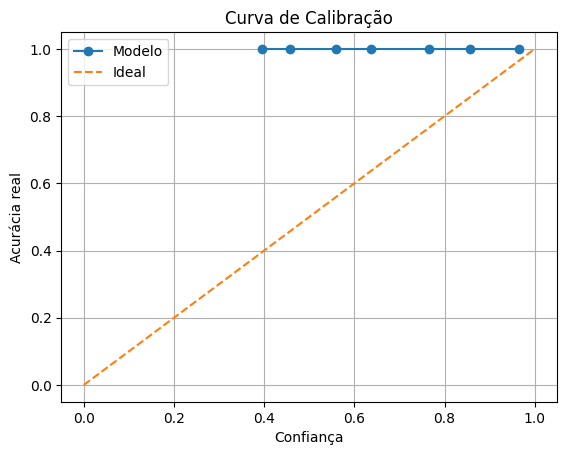

In [34]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_calibration_curve(y_true, y_probs, num_bins=10):

    # confiança máxima por amostra
    confidences = y_probs.max(axis=1)
    predictions = y_probs.argmax(axis=1)

    # correto ou não
    correct = (predictions == y_true).astype(int)

    prob_true, prob_pred = calibration_curve(correct, confidences, n_bins=num_bins)

    plt.figure()
    plt.plot(prob_pred, prob_true, marker='o', label='Modelo')
    plt.plot([0,1], [0,1], linestyle='--', label='Ideal')

    plt.xlabel('Confiança')
    plt.ylabel('Acurácia real')
    plt.title('Curva de Calibração')
    plt.legend()
    plt.grid()

    plt.show()
plot_calibration_curve(y_true, y_probs)

In [32]:
def analyze_low_confidence(y_true, y_pred, y_probs, threshold=0.6):

    confidences = y_probs.max(axis=1)

    low_conf_idx = np.where(confidences < threshold)[0]

    print(f"Total de amostras com baixa confiança (<{threshold}):", len(low_conf_idx))

    for i in low_conf_idx:
        print(f"\nAmostra {i}")
        print(f"Verdadeiro: {y_true[i]}")
        print(f"Predito: {y_pred[i]}")
        print(f"Confiança: {confidences[i]:.4f}")
        print(f"Probabilidades: {y_probs[i]}")



analyze_low_confidence(y_true, y_pred, y_probs, threshold=0.6)

Total de amostras com baixa confiança (<0.6): 7

Amostra 2
Verdadeiro: 0
Predito: 0
Confiança: 0.5237
Probabilidades: [0.52367795 0.07351198 0.40281016]

Amostra 6
Verdadeiro: 0
Predito: 0
Confiança: 0.5914
Probabilidades: [0.5914427  0.27133462 0.13722272]

Amostra 9
Verdadeiro: 0
Predito: 0
Confiança: 0.3948
Probabilidades: [0.39481062 0.22775604 0.37743342]

Amostra 25
Verdadeiro: 0
Predito: 0
Confiança: 0.5627
Probabilidades: [0.56272817 0.3090087  0.12826324]

Amostra 30
Verdadeiro: 2
Predito: 2
Confiança: 0.4871
Probabilidades: [0.47289157 0.03998824 0.48712024]

Amostra 42
Verdadeiro: 1
Predito: 1
Confiança: 0.4188
Probabilidades: [0.35823393 0.41881827 0.22294785]

Amostra 46
Verdadeiro: 0
Predito: 0
Confiança: 0.4660
Probabilidades: [0.4660126  0.1538265  0.38016093]


In [33]:
def compare_with_individual_models(models, dataloader, y_true, target_indices):

    for name, model in models.items():

        print(f"\nModelo: {name}")

        all_preds = []

        for images, _ in dataloader:
            images = images.to(device)

            with torch.no_grad():
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())

        all_preds = np.array(all_preds)

        errors = 0

        for i in target_indices:
            if all_preds[i] != y_true[i]:
                errors += 1

        print(f"Erros nas amostras difíceis: {errors}/{len(target_indices)}")

        # índices das amostras com baixa confiança
# índices das amostras com baixa confiança
confidences = y_probs.max(axis=1)
low_idx = np.where(confidences < 0.6)[0]

compare_with_individual_models(
    models_20x,
    val_loader_20x,
    y_true,
    low_idx
)


Modelo: best_Rand_densenet121_20x


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Erros nas amostras difíceis: 4/7

Modelo: best_Rand_efficientnet_b3_20x
Erros nas amostras difíceis: 4/7

Modelo: best_Rand_vit_b16_20x
Erros nas amostras difíceis: 2/7

Modelo: best_Rand_resnet50_20x
Erros nas amostras difíceis: 2/7

Modelo: best_Rand_convnext_tiny_20x
Erros nas amostras difíceis: 2/7


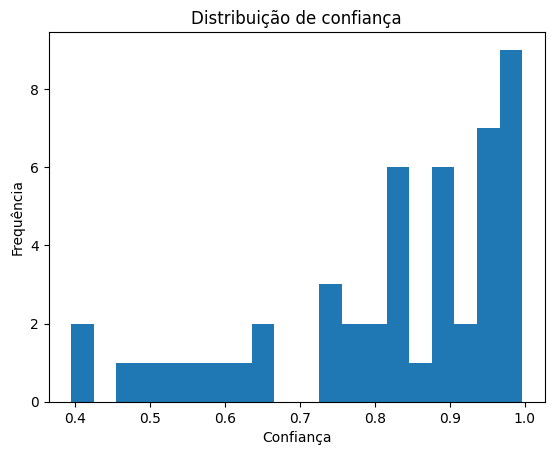

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(max_probs, bins=20)
plt.title("Distribuição de confiança")
plt.xlabel("Confiança")
plt.ylabel("Frequência")
plt.show()

In [25]:
print("\n===== ENSEMBLE 40x =====")

acc, auc, kappa, f1 = evaluate_ensemble(models_list_40x, val_loader_40x, "hard")
print(f"Hard Voting  → Acc: {acc:.4f} | AUC: {auc:.4f} | Kappa: {kappa:.4f} | F1-macro: {f1:.4f}")

acc, auc, kappa, f1 = evaluate_ensemble(models_list_40x, val_loader_40x, "soft")
print(f"Soft Voting  → Acc: {acc:.4f} | AUC: {auc:.4f} | Kappa: {kappa:.4f} | F1-macro: {f1:.4f}")

acc, auc, kappa, f1 = evaluate_ensemble(models_list_40x, val_loader_40x, "weighted", weights_40x)
print(f"Weighted     → Acc: {acc:.4f} | AUC: {auc:.4f} | Kappa: {kappa:.4f} | F1-macro: {f1:.4f}")


===== ENSEMBLE 40x =====


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Hard Voting  → Acc: 0.9348 | AUC: 0.9513 | Kappa: 0.9021 | F1-macro: 0.9339


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Soft Voting  → Acc: 0.9348 | AUC: 0.9780 | Kappa: 0.9021 | F1-macro: 0.9339


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Weighted     → Acc: 0.9348 | AUC: 0.9780 | Kappa: 0.9021 | F1-macro: 0.9339
